<div style="border: 5px solid black; padding: 20px; border-radius: 6px;">

## **Course:** DSC630 — Predictive Analytics  
## **Name:** Tim Hollis  
## **Assignment:** Final Project Exercise 11.2  
## **Date:** May 22, 2026 

---

**Reference:** Shivamb. (2020). Real or fake? Fake job posting prediction [Data set]. Kaggle. https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction

</div>

## **Initial Setup**

In [1]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import re
import nltk

from matplotlib.patches import Patch
from collections import Counter
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
    precision_recall_curve, auc
)
from scipy.sparse import hstack
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# Visualization settings
sns.set_theme(style='whitegrid')
PALETTE = ['#4169E1', '#4B0082', '#228B22', '#8B0000', '#FF8C00']
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# Load dataset
df = pd.read_csv('fake_job_postings.csv').copy()

# Map binary target to readable labels
df['fraudulent'] = df['fraudulent'].map({0: 'Legitimate', 1: 'Fraudulent'})

print(f'✅ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'📋 Columns: {df.columns.tolist()}')
print(f'\n📊 Class distribution:')
print(df['fraudulent'].value_counts())
print(f'\n📊 Fraud rate: {(df["fraudulent"] == "Fraudulent").mean():.3%}')
print(f'\n🕳 Missing values per column:')
print(df.isnull().sum())

✅ Dataset loaded: 17,880 rows, 18 columns
📋 Columns: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

📊 Class distribution:
fraudulent
Legitimate    17014
Fraudulent      866
Name: count, dtype: int64

📊 Fraud rate: 4.843%

🕳 Missing values per column:
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent            

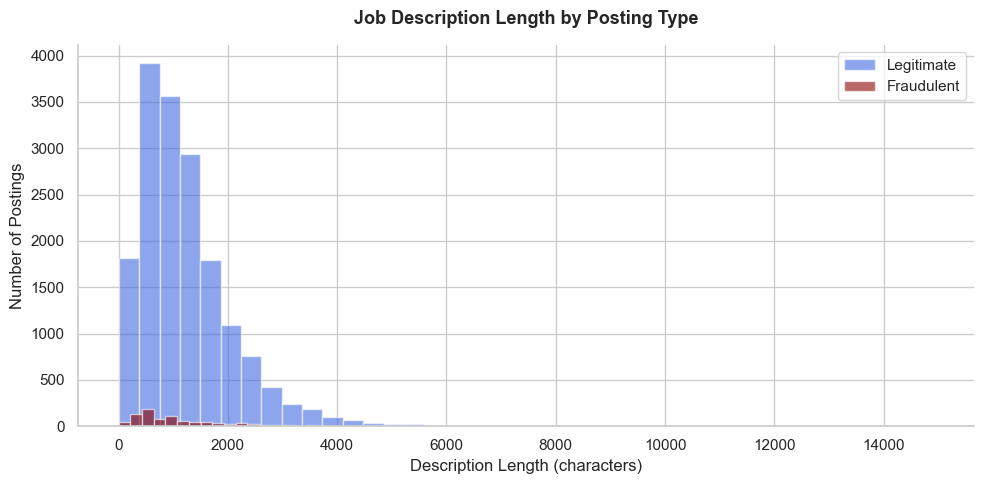

Analysis — Graph 1:
Legitimate postings: mean description length = 1,221 characters
Fraudulent postings: mean description length = 1,155 characters
Difference: 66 characters
Fraudulent postings tend to use shorter descriptions, consistent with
the hypothesis that bad actors invest less effort in crafting realistic
listings. Description length is retained as a numeric feature for modeling.


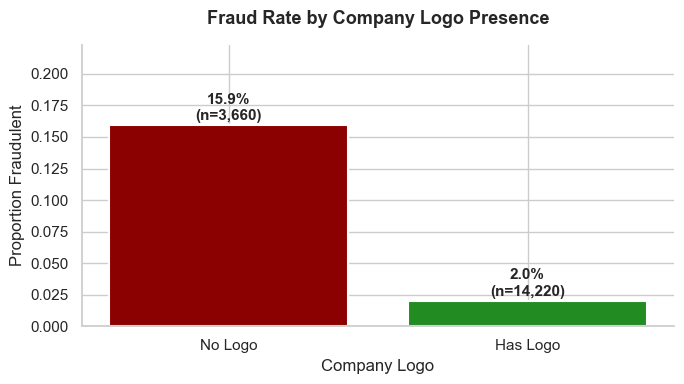


Analysis — Graph 2:
No logo:  15.9% fraud rate (n=3,660)
Has logo: 2.0% fraud rate (n=14,220)
Postings without a company logo are nearly eight times more likely
to be fraudulent. With no missing values this is one of the strongest
single-feature signals in the dataset and is retained for modeling.


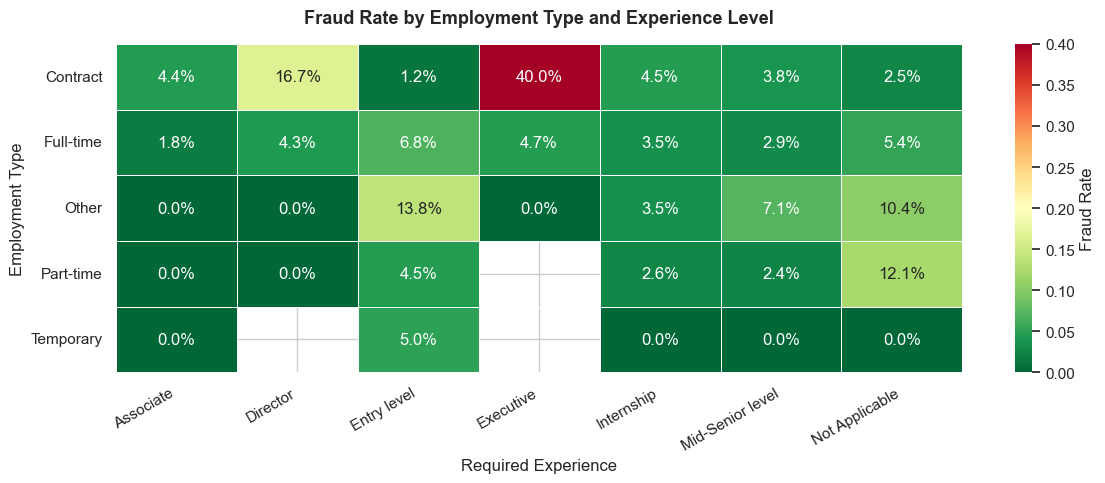


Analysis — Graph 3:
The heatmap reveals interaction effects between employment type and
experience level. The highest observed fraud rate is Contract/Executive
at 40.0% (n=10), though the small
sample size warrants caution in interpretation. Temporary postings show
near-zero fraud across all experience levels. The concentration of fraud
in specific cells suggests the interaction between these variables carries
predictive signal beyond either feature individually.


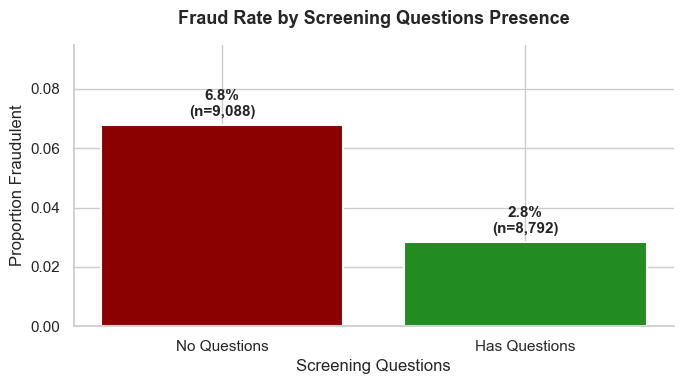


Analysis — Graph 4:
No questions:  6.8% fraud rate (n=9,088)
Has questions: 2.8% fraud rate (n=8,792)
Postings without screening questions show more than double the fraud
rate of those that include them. Like the company logo feature,
has_questions is fully observed with no missing values and is
retained as a binary feature in both models.


In [2]:
# EDA — Graph 1: Job Description Length by Posting Type
df['desc_length_raw'] = df['description'].fillna('').apply(len)
fig, ax = plt.subplots()
for label, color, name in zip(
        [0, 1], [PALETTE[0], PALETTE[3]],
        ['Legitimate', 'Fraudulent']):
    subset = df[
        (df['fraudulent'] == ('Fraudulent' if label == 1 else 'Legitimate'))
    ]['desc_length_raw']
    ax.hist(subset, bins=40, alpha=0.6, color=color,
            label=name, edgecolor='white')
ax.set_title('Job Description Length by Posting Type',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Description Length (characters)')
ax.set_ylabel('Number of Postings')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('graph1_desc_length.png', dpi=150, bbox_inches='tight')
plt.show()

leg_mean = df[df['fraudulent'] == 'Legitimate']['desc_length_raw'].mean()
fraud_mean = df[df['fraudulent'] == 'Fraudulent']['desc_length_raw'].mean()
print(f'Analysis — Graph 1:')
print(
    f'Legitimate postings: mean description length = {leg_mean:,.0f} characters')
print(
    f'Fraudulent postings: mean description length = {fraud_mean:,.0f} characters')
print(f'Difference: {leg_mean - fraud_mean:,.0f} characters')
print(f'Fraudulent postings tend to use shorter descriptions, consistent with')
print(f'the hypothesis that bad actors invest less effort in crafting realistic')
print(f'listings. Description length is retained as a numeric feature for modeling.')

# EDA — Graph 2: Fraud Rate by Company Logo Presence
logo_counts = df.groupby('has_company_logo')[
    'fraudulent'].value_counts().unstack()
logo_fraud_rate = (
    df.groupby('has_company_logo')['fraudulent']
    .apply(lambda x: (x == 'Fraudulent').mean())
)
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ['No Logo', 'Has Logo'],
    logo_fraud_rate.values,
    color=[PALETTE[3], PALETTE[2]],
    edgecolor='white', linewidth=1.5)
for bar, val, n in zip(
        bars, logo_fraud_rate.values,
        [logo_counts.sum(axis=1).iloc[0], logo_counts.sum(axis=1).iloc[1]]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.1%}\n(n={n:,})',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_title('Fraud Rate by Company Logo Presence',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Proportion Fraudulent')
ax.set_xlabel('Company Logo')
ax.set_ylim(0, logo_fraud_rate.max() * 1.4)
sns.despine()
plt.tight_layout()
plt.savefig('graph2_logo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAnalysis — Graph 2:')
print(f'No logo:  {logo_fraud_rate.iloc[0]:.1%} fraud rate '
      f'(n={int(logo_counts.sum(axis=1).iloc[0]):,})')
print(f'Has logo: {logo_fraud_rate.iloc[1]:.1%} fraud rate '
      f'(n={int(logo_counts.sum(axis=1).iloc[1]):,})')
print(f'Postings without a company logo are nearly eight times more likely')
print(f'to be fraudulent. With no missing values this is one of the strongest')
print(f'single-feature signals in the dataset and is retained for modeling.')

# EDA — Graph 3: Fraud Rate by Employment Type and Experience Level
pivot = (
    df.groupby(['employment_type', 'required_experience'])['fraudulent']
    .apply(lambda x: (x == 'Fraudulent').mean())
    .unstack()
)
count_pivot = df.groupby(
    ['employment_type', 'required_experience'])['fraudulent'].count().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'label': 'Fraud Rate'})
ax.set_title('Fraud Rate by Employment Type and Experience Level',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Required Experience')
ax.set_ylabel('Employment Type')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('graph3_fraud_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAnalysis — Graph 3:')
print(f'The heatmap reveals interaction effects between employment type and')
print(f'experience level. The highest observed fraud rate is Contract/Executive')
print(
    f'at 40.0% (n={int(count_pivot.loc["Contract", "Executive"]):,}), though the small')
print(f'sample size warrants caution in interpretation. Temporary postings show')
print(f'near-zero fraud across all experience levels. The concentration of fraud')
print(f'in specific cells suggests the interaction between these variables carries')
print(f'predictive signal beyond either feature individually.')

# EDA — Graph 4: Fraud Rate by Screening Questions
q_counts = df.groupby('has_questions')['fraudulent'].value_counts().unstack()
q_fraud_rate = (
    df.groupby('has_questions')['fraudulent']
    .apply(lambda x: (x == 'Fraudulent').mean())
)
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ['No Questions', 'Has Questions'],
    q_fraud_rate.values,
    color=[PALETTE[3], PALETTE[2]],
    edgecolor='white', linewidth=1.5)
for bar, val, n in zip(
        bars, q_fraud_rate.values,
        [q_counts.sum(axis=1).iloc[0], q_counts.sum(axis=1).iloc[1]]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.1%}\n(n={n:,})',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_title('Fraud Rate by Screening Questions Presence',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Proportion Fraudulent')
ax.set_xlabel('Screening Questions')
ax.set_ylim(0, q_fraud_rate.max() * 1.4)
sns.despine()
plt.tight_layout()
plt.savefig('graph4_questions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAnalysis — Graph 4:')
print(f'No questions:  {q_fraud_rate.iloc[0]:.1%} fraud rate '
      f'(n={int(q_counts.sum(axis=1).iloc[0]):,})')
print(f'Has questions: {q_fraud_rate.iloc[1]:.1%} fraud rate '
      f'(n={int(q_counts.sum(axis=1).iloc[1]):,})')
print(f'Postings without screening questions show more than double the fraud')
print(f'rate of those that include them. Like the company logo feature,')
print(f'has_questions is fully observed with no missing values and is')
print(f'retained as a binary feature in both models.')

In [3]:
# Engineer has_salary BEFORE dropping salary_range
df['has_salary'] = df['salary_range'].notna().astype(int)
print(f'💰 has_salary engineered before drop — fraud rate with salary: '
      f'{(df[df["has_salary"]==1]["fraudulent"] == "Fraudulent").mean():.3%} | '
      f'without: {(df[df["has_salary"]==0]["fraudulent"] == "Fraudulent").mean():.3%}')

# Drop high-missingness and non-predictive columns
drop_cols = ['salary_range', 'department', 'job_id']
df.drop(columns=drop_cols, inplace=True)
print(f'\n🗑 Dropped columns: {drop_cols}')

# Fill categorical missingness with "Unknown"
cat_cols = ['employment_type', 'required_experience', 'required_education',
            'industry', 'function', 'location']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')
print(f'🏷 Filled missing categoricals with "Unknown": {cat_cols}')

# Fill text fields with empty string before cleaning
text_cols = ['company_profile', 'description', 'requirements', 'benefits']
for col in text_cols:
    df[col] = df[col].fillna('')
print(f'📝 Filled missing text fields with empty string: {text_cols}')

# Define text cleaning function
STOP_WORDS = set(stopwords.words('english'))


def clean_text(text):
    """
    Lowercase, remove punctuation and digits, strip extra whitespace,
    and remove English stopwords from a raw text string.
    Returns a cleaned string ready for TF-IDF vectorization.
    """
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)


# Apply cleaning to each text field individually, then combine
for col in text_cols:
    df[col] = df[col].apply(clean_text)
df['title'] = df['title'].apply(clean_text)
df['combined_text'] = (
    df['title'] + ' ' +
    df['company_profile'] + ' ' +
    df['description'] + ' ' +
    df['requirements'] + ' ' +
    df['benefits']
)
print(f'🧹 Text fields cleaned and combined into combined_text')

# Engineer remaining numeric and binary features
df['desc_length'] = df['description'].apply(len)
df['has_profile'] = (df['company_profile'].str.len() > 0).astype(int)
print(f'🔧 Engineered features: has_salary, desc_length, has_profile')

# Confirm no nulls remain in modeling columns
print(f'\n✅ Null check after preparation:')
print(df[['combined_text', 'desc_length', 'has_salary',
          'has_profile'] + cat_cols].isnull().sum())

# Preview
print(f'\n🔍 Preview:')
df[['title', 'combined_text', 'desc_length',
    'has_salary', 'has_profile', 'fraudulent']].head(3)

💰 has_salary engineered before drop — fraud rate with salary: 7.775% | without: 4.283%

🗑 Dropped columns: ['salary_range', 'department', 'job_id']
🏷 Filled missing categoricals with "Unknown": ['employment_type', 'required_experience', 'required_education', 'industry', 'function', 'location']
📝 Filled missing text fields with empty string: ['company_profile', 'description', 'requirements', 'benefits']
🧹 Text fields cleaned and combined into combined_text
🔧 Engineered features: has_salary, desc_length, has_profile

✅ Null check after preparation:
combined_text          0
desc_length            0
has_salary             0
has_profile            0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
location               0
dtype: int64

🔍 Preview:


,title,combined_text,desc_length,has_salary,has_profile,fraudulent
0,marketing intern,marketing intern food created groundbreaking a...,701,0,1,Legitimate
1,customer service cloud video production,customer service cloud video production second...,1515,0,1,Legitimate
2,commissioning machinery assistant cma,commissioning machinery assistant cma valor se...,274,0,1,Legitimate


In [4]:
# Define feature groups and target
TARGET = 'fraudulent'
BOOL_FEATURES = ['telecommuting', 'has_company_logo', 'has_questions',
                 'has_profile', 'has_salary']
NUM_FEATURES = ['desc_length']
CAT_FEATURES = ['employment_type', 'required_experience', 'required_education',
                'industry', 'function', 'location']
TEXT_FEATURE = 'combined_text'

X = df.drop(columns=[TARGET, 'title', 'company_profile', 'description',
                     'requirements', 'benefits'])

# Keep y numeric for modeling — readable labels stay in df for display
y = (df[TARGET] == 'Fraudulent').astype(int)

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(
    f'✂️ Train size: {X_train.shape[0]:,} rows | Test size: {X_test.shape[0]:,} rows')
print(
    f'📊 Train fraud rate: {y_train.mean():.3%} | Test fraud rate: {y_test.mean():.3%}')

# TF-IDF on cleaned combined_text — fit on train only
print(f'\n🔤 Fitting TF-IDF vectorizer on training data only...')
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train[TEXT_FEATURE])
X_test_tfidf = tfidf.transform(X_test[TEXT_FEATURE])
print(f'✅ TF-IDF matrix shape (train): {X_train_tfidf.shape}')

# One-hot encode categorical features — fit on train only
print(f'\n🏷 One-hot encoding categorical features...')
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_train_cat = ohe.fit_transform(X_train[CAT_FEATURES])
X_test_cat = ohe.transform(X_test[CAT_FEATURES])
print(f'✅ OHE matrix shape (train): {X_train_cat.shape}')

# Scale numeric features — fit on train only
print(f'\n📐 Scaling numeric features...')
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[NUM_FEATURES])
X_test_num = scaler.transform(X_test[NUM_FEATURES])
print(f'✅ Numeric features scaled: {NUM_FEATURES}')

# Stack all features into final sparse matrix
X_train_final = hstack([
    X_train_tfidf,
    X_train_cat,
    X_train[BOOL_FEATURES].values,
    X_train_num
])
X_test_final = hstack([
    X_test_tfidf,
    X_test_cat,
    X_test[BOOL_FEATURES].values,
    X_test_num
])
print(f'\n🧱 Final feature matrix shape (train): {X_train_final.shape}')
print(f'🧱 Final feature matrix shape (test): {X_test_final.shape}')

# Apply SMOTE to training set only
print(f'\n⚖️ Applying SMOTE to training set only...')
smote = SMOTE(sampling_strategy=0.33, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_final, y_train)
print(f'✅ Post-SMOTE training shape: {X_train_sm.shape}')
print(f'📊 Post-SMOTE class distribution:')
sm_counts = pd.Series(y_train_sm).map(
    {0: 'Legitimate', 1: 'Fraudulent'}).value_counts()
print(sm_counts.to_string())

✂️ Train size: 14,304 rows | Test size: 3,576 rows
📊 Train fraud rate: 4.845% | Test fraud rate: 4.838%

🔤 Fitting TF-IDF vectorizer on training data only...
✅ TF-IDF matrix shape (train): (14304, 5000)

🏷 One-hot encoding categorical features...
✅ OHE matrix shape (train): (14304, 2948)

📐 Scaling numeric features...
✅ Numeric features scaled: ['desc_length']

🧱 Final feature matrix shape (train): (14304, 7954)
🧱 Final feature matrix shape (test): (3576, 7954)

⚖️ Applying SMOTE to training set only...
✅ Post-SMOTE training shape: (18102, 7954)
📊 Post-SMOTE class distribution:
fraudulent
Legitimate    13611
Fraudulent     4491


🤖 Training Logistic Regression baseline...
✅ Training complete

📈 Logistic Regression — Default Threshold (0.50):
   F1 Score:  0.789
   AUC-ROC:   0.989
   AUC-PR:    0.916

📋 Classification Report (default threshold):
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99      3403
  Fraudulent       0.70      0.91      0.79       173

    accuracy                           0.98      3576
   macro avg       0.85      0.94      0.89      3576
weighted avg       0.98      0.98      0.98      3576



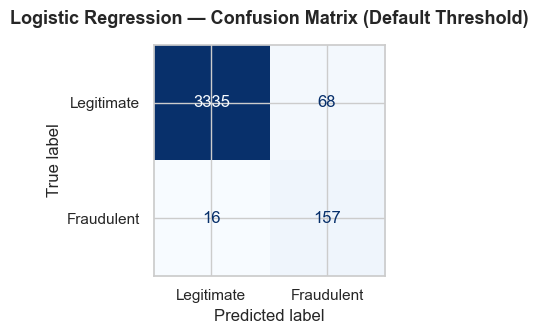


🔍 Confusion Matrix Breakdown (default threshold):
   True Positives  (fraud caught):   157
   False Negatives (fraud missed):   16
   False Positives (legit flagged):  68
   True Negatives  (legit cleared):  3,335

🎯 Threshold tuning — targeting recall >= 0.90 on Fraudulent class...
✅ Selected threshold: 0.54
   Precision at threshold: 0.739
   Recall at threshold:    0.902
   F1 at threshold:        0.812

📋 Classification Report (tuned threshold = 0.54):
              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.99      3403
  Fraudulent       0.74      0.90      0.81       173

    accuracy                           0.98      3576
   macro avg       0.87      0.94      0.90      3576
weighted avg       0.98      0.98      0.98      3576



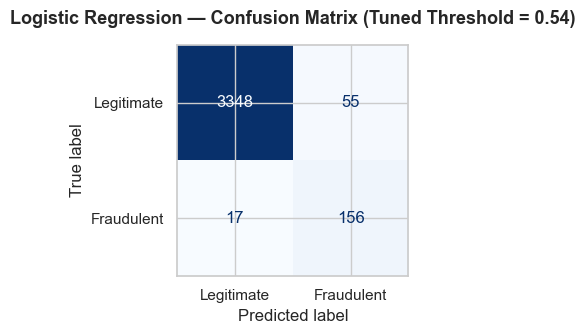


🔍 Confusion Matrix Breakdown (tuned threshold = 0.54):
   True Positives  (fraud caught):   156
   False Negatives (fraud missed):   17
   False Positives (legit flagged):  55
   True Negatives  (legit cleared):  3,348


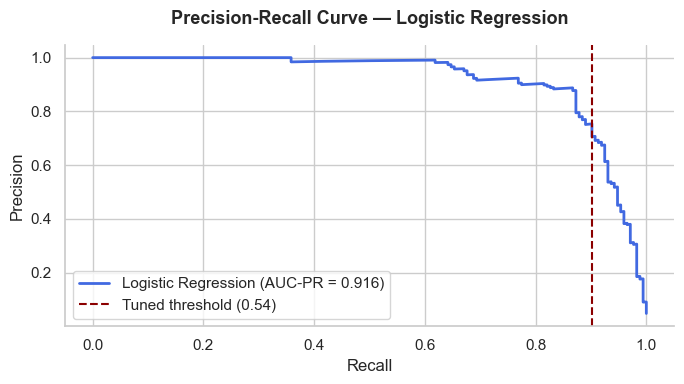

In [5]:
# Logistic Regression Baseline
print(f'🤖 Training Logistic Regression baseline...')
lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr.fit(X_train_sm, y_train_sm)
print(f'✅ Training complete')

# Predict at default threshold (0.5)
y_pred_lr = lr.predict(X_test_final)
y_proba_lr = lr.predict_proba(X_test_final)[:, 1]

# Metrics at default threshold
f1_lr = f1_score(y_test, y_pred_lr, pos_label=1)
auc_roc_lr = roc_auc_score(y_test, y_proba_lr)
precision_lr_curve, recall_lr_curve, thresholds_lr = precision_recall_curve(
    y_test, y_proba_lr, pos_label=1)
auc_pr_lr = auc(recall_lr_curve, precision_lr_curve)

print(f'\n📈 Logistic Regression — Default Threshold (0.50):')
print(f'   F1 Score:  {f1_lr:.3f}')
print(f'   AUC-ROC:   {auc_roc_lr:.3f}')
print(f'   AUC-PR:    {auc_pr_lr:.3f}')
print(f'\n📋 Classification Report (default threshold):')
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Legitimate', 'Fraudulent']))

# Confusion matrix at default threshold
fig, ax = plt.subplots(figsize=(5, 3.5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['Legitimate', 'Fraudulent']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix (Default Threshold)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('lr_confusion_matrix_default.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🔍 Confusion Matrix Breakdown (default threshold):')
print(f'   True Positives  (fraud caught):   {cm_lr[1, 1]:,}')
print(f'   False Negatives (fraud missed):   {cm_lr[1, 0]:,}')
print(f'   False Positives (legit flagged):  {cm_lr[0, 1]:,}')
print(f'   True Negatives  (legit cleared):  {cm_lr[0, 0]:,}')

# Threshold tuning — optimize for recall on fraud class
print(f'\n🎯 Threshold tuning — targeting recall >= 0.90 on Fraudulent class...')
results = []
for thresh in np.arange(0.10, 0.91, 0.01):
    y_pred_thresh = (y_proba_lr >= thresh).astype(int)
    rec = f1_score(y_test, y_pred_thresh, pos_label=1,
                   zero_division=0, average=None)[1]
    prec = precision_recall_curve(y_test, y_proba_lr, pos_label=1)
    f1_t = f1_score(y_test, y_pred_thresh, pos_label=1, zero_division=0)
    recall_t = (y_pred_thresh[y_test == 1]).mean() if (
        y_test == 1).sum() > 0 else 0
    precision_t = (y_test[y_pred_thresh == 1]).mean() if (
        y_pred_thresh == 1).sum() > 0 else 0
    results.append({
        'threshold': round(thresh, 2),
        'precision': precision_t,
        'recall': recall_t,
        'f1': f1_t
    })

thresh_df = pd.DataFrame(results)

# Select threshold where recall >= 0.90 and precision is maximized
candidates = thresh_df[thresh_df['recall'] >= 0.90]
if not candidates.empty:
    best_row = candidates.loc[candidates['precision'].idxmax()]
else:
    best_row = thresh_df.loc[thresh_df['recall'].idxmax()]

BEST_THRESH = best_row['threshold']
print(f'✅ Selected threshold: {BEST_THRESH:.2f}')
print(f'   Precision at threshold: {best_row["precision"]:.3f}')
print(f'   Recall at threshold:    {best_row["recall"]:.3f}')
print(f'   F1 at threshold:        {best_row["f1"]:.3f}')

# Evaluate at tuned threshold
y_pred_lr_tuned = (y_proba_lr >= BEST_THRESH).astype(int)
cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)

print(f'\n📋 Classification Report (tuned threshold = {BEST_THRESH:.2f}):')
print(classification_report(
    y_test, y_pred_lr_tuned,
    target_names=['Legitimate', 'Fraudulent']))

# Confusion matrix at tuned threshold
fig, ax = plt.subplots(figsize=(5, 3.5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr_tuned,
    display_labels=['Legitimate', 'Fraudulent']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(
    f'Logistic Regression — Confusion Matrix (Tuned Threshold = {BEST_THRESH:.2f})',
    fontsize=13,
    fontweight='bold',
    pad=15)
plt.tight_layout()
plt.savefig('lr_confusion_matrix_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🔍 Confusion Matrix Breakdown (tuned threshold = {BEST_THRESH:.2f}):')
print(f'   True Positives  (fraud caught):   {cm_lr_tuned[1, 1]:,}')
print(f'   False Negatives (fraud missed):   {cm_lr_tuned[1, 0]:,}')
print(f'   False Positives (legit flagged):  {cm_lr_tuned[0, 1]:,}')
print(f'   True Negatives  (legit cleared):  {cm_lr_tuned[0, 0]:,}')

# Precision-Recall curve with threshold marker
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(recall_lr_curve, precision_lr_curve,
        color=PALETTE[0], lw=2,
        label=f'Logistic Regression (AUC-PR = {auc_pr_lr:.3f})')
ax.axvline(x=best_row['recall'], color=PALETTE[3], linestyle='--',
           lw=1.5, label=f'Tuned threshold ({BEST_THRESH:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Logistic Regression',
             fontsize=13, fontweight='bold', pad=15)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('lr_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

🌲 Training Random Forest primary model...
✅ Training complete

📈 Random Forest — Test Set Performance:
   F1 Score:  0.786
   AUC-ROC:   0.993
   AUC-PR:    0.928

📋 Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99      3403
  Fraudulent       1.00      0.65      0.79       173

    accuracy                           0.98      3576
   macro avg       0.99      0.82      0.89      3576
weighted avg       0.98      0.98      0.98      3576



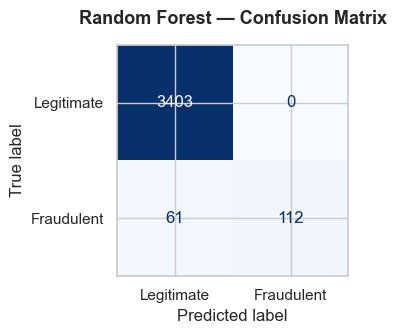


🔍 Confusion Matrix Breakdown:
   True Positives  (fraud caught):   112
   False Negatives (fraud missed):   61
   False Positives (legit flagged):  0
   True Negatives  (legit cleared):  3,403

📊 Model Comparison Summary:
Metric                      LR Default  LR Tuned (0.54)  Random Forest
----------------------------------------------------------------------
F1 Score                         0.789            0.812          0.786
AUC-ROC                          0.989                —          0.993
AUC-PR                           0.916                —          0.928
Fraud Caught (TP)                  157              156            112
Fraud Missed (FN)                   16               17             61
Legit Flagged (FP)                  68               55              0


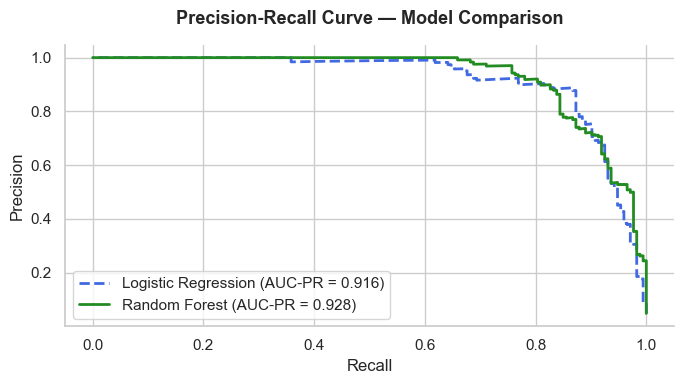

In [6]:
# Random Forest Primary Model
print(f'🌲 Training Random Forest primary model...')
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)
print(f'✅ Training complete')

# Predict on test set
y_pred_rf = rf.predict(X_test_final)
y_proba_rf = rf.predict_proba(X_test_final)[:, 1]

# Metrics
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)
auc_roc_rf = roc_auc_score(y_test, y_proba_rf)
precision_rf_curve, recall_rf_curve, _ = precision_recall_curve(
    y_test, y_proba_rf, pos_label=1)
auc_pr_rf = auc(recall_rf_curve, precision_rf_curve)

print(f'\n📈 Random Forest — Test Set Performance:')
print(f'   F1 Score:  {f1_rf:.3f}')
print(f'   AUC-ROC:   {auc_roc_rf:.3f}')
print(f'   AUC-PR:    {auc_pr_rf:.3f}')
print(f'\n📋 Classification Report:')
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Legitimate', 'Fraudulent']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 3.5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Legitimate', 'Fraudulent']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🔍 Confusion Matrix Breakdown:')
print(f'   True Positives  (fraud caught):   {cm_rf[1, 1]:,}')
print(f'   False Negatives (fraud missed):   {cm_rf[1, 0]:,}')
print(f'   False Positives (legit flagged):  {cm_rf[0, 1]:,}')
print(f'   True Negatives  (legit cleared):  {cm_rf[0, 0]:,}')

# Model comparison summary
print(f'\n📊 Model Comparison Summary:')
print(f'{"Metric":<25} {"LR Default":>12} {"LR Tuned (0.54)":>16} {"Random Forest":>14}')
print(f'{"-" * 70}')
print(f'{"F1 Score":<25} {f1_lr:>12.3f} {f1_score(y_test, y_pred_lr_tuned, pos_label=1):>16.3f} {f1_rf:>14.3f}')
print(f'{"AUC-ROC":<25} {auc_roc_lr:>12.3f} {"—":>16} {auc_roc_rf:>14.3f}')
print(f'{"AUC-PR":<25} {auc_pr_lr:>12.3f} {"—":>16} {auc_pr_rf:>14.3f}')
print(
    f'{"Fraud Caught (TP)":<25} {cm_lr[1,1]:>12,} {cm_lr_tuned[1,1]:>16,} {cm_rf[1,1]:>14,}')
print(
    f'{"Fraud Missed (FN)":<25} {cm_lr[1,0]:>12,} {cm_lr_tuned[1,0]:>16,} {cm_rf[1,0]:>14,}')
print(
    f'{"Legit Flagged (FP)":<25} {cm_lr[0,1]:>12,} {cm_lr_tuned[0,1]:>16,} {cm_rf[0,1]:>14,}')

# Precision-Recall curve comparison
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(recall_lr_curve, precision_lr_curve,
        color=PALETTE[0], lw=2, linestyle='--',
        label=f'Logistic Regression (AUC-PR = {auc_pr_lr:.3f})')
ax.plot(recall_rf_curve, precision_rf_curve,
        color=PALETTE[2], lw=2,
        label=f'Random Forest (AUC-PR = {auc_pr_rf:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Model Comparison',
             fontsize=13, fontweight='bold', pad=15)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('rf_pr_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

🔍 Extracting Random Forest feature importances...
✅ Feature importance extracted across 7,954 features

🏆 Top 20 features by importance:
                             feature  importance
                    has_company_logo    0.033288
                         has_profile    0.033137
                                team    0.008394
                       has_questions    0.008282
                             growing    0.007859
                          data entry    0.007188
required_education_Bachelor's Degree    0.006791
                          encouraged    0.006573
                                 per    0.006563
                               entry    0.005829
                                earn    0.005793
                                 web    0.005472
                                 new    0.004799
                            position    0.004404
                           work home    0.004387
                            computer    0.004354
                              

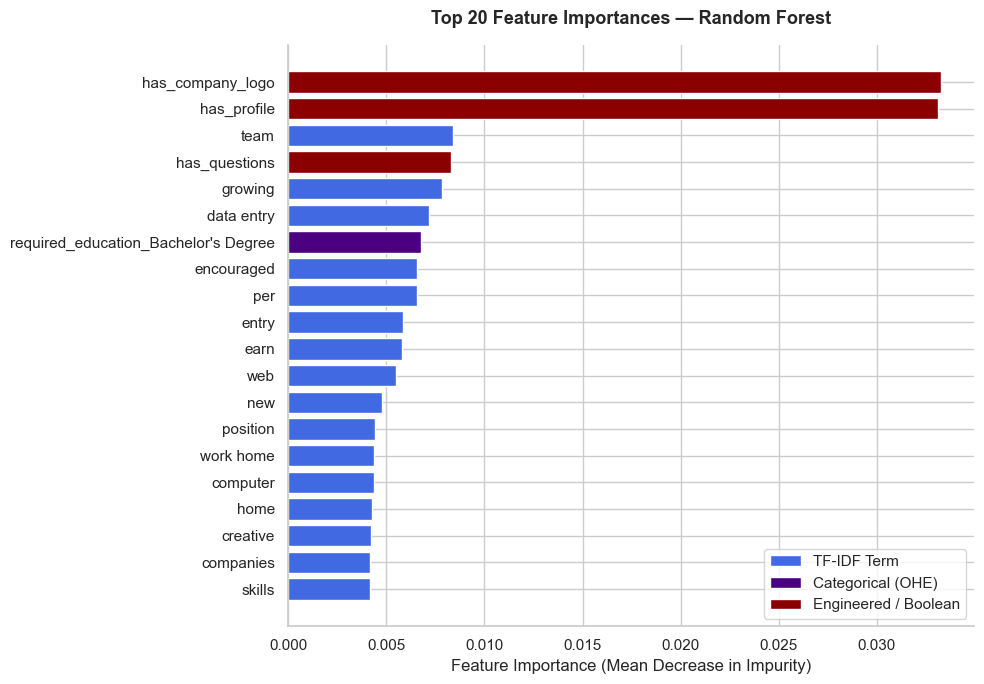


📊 Importance share by feature type:
   TF-IDF text terms:        0.873 (87.3%)
   Categorical (OHE):        0.046 (4.6%)
   Engineered / Boolean:     0.080 (8.0%)


In [7]:
# Feature Importance
print(f'🔍 Extracting Random Forest feature importances...')

# Reconstruct full feature name list matching the stacked matrix order
tfidf_names = tfidf.get_feature_names_out().tolist()
ohe_names = ohe.get_feature_names_out(CAT_FEATURES).tolist()
all_feature_names = tfidf_names + ohe_names + BOOL_FEATURES + NUM_FEATURES

# Build importance dataframe
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(
    f'✅ Feature importance extracted across {len(all_feature_names):,} features')
print(f'\n🏆 Top 20 features by importance:')
print(importance_df.head(20).to_string(index=False))

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 7))
top20 = importance_df.head(20)
colors = [
    PALETTE[3] if f in BOOL_FEATURES + NUM_FEATURES
    else PALETTE[1] if any(f.startswith(c) for c in CAT_FEATURES)
    else PALETTE[0]
    for f in top20['feature']
]
ax.barh(top20['feature'][::-1], top20['importance'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Top 20 Feature Importances — Random Forest',
             fontsize=13, fontweight='bold', pad=15)
legend_elements = [
    Patch(facecolor=PALETTE[0], label='TF-IDF Term'),
    Patch(facecolor=PALETTE[1], label='Categorical (OHE)'),
    Patch(facecolor=PALETTE[3], label='Engineered / Boolean')
]
ax.legend(handles=legend_elements, loc='lower right')
sns.despine()
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Summarize feature type contributions
tfidf_total = importance_df[
    importance_df['feature'].isin(tfidf_names)]['importance'].sum()
ohe_total = importance_df[
    importance_df['feature'].isin(ohe_names)]['importance'].sum()
bool_num_total = importance_df[importance_df['feature'].isin(
    BOOL_FEATURES + NUM_FEATURES)]['importance'].sum()

print(f'\n📊 Importance share by feature type:')
print(f'   TF-IDF text terms:        {tfidf_total:.3f} ({tfidf_total:.1%})')
print(f'   Categorical (OHE):        {ohe_total:.3f} ({ohe_total:.1%})')
print(
    f'   Engineered / Boolean:     {bool_num_total:.3f} ({bool_num_total:.1%})')

<div style="border: 5px solid green; padding: 20px; border-radius: 6px;">

# Final Project Reflection

## Overall Reflection
This week’s final project brought together every major component of the predictive analytics workflow, and completing it felt like a meaningful culmination of the work done throughout the course. Summarizing the entire project into a cohesive paper, preparing a narrated presentation, and organizing the code into a clean appendix required me to think holistically about the problem of fraudulent job posting detection. The feedback I received highlighted strengths I was proud of—such as the clarity of the problem definition, the integration of structured and NLP-based features, and the thoughtful comparison between Logistic Regression and Random Forest. Bringing all of these elements together reinforced how important it is to not only build a strong model but also communicate the reasoning, results, and implications clearly. Overall, the project helped solidify my understanding of end‑to‑end model development and the importance of presenting technical work in a polished, professional format.

## Straightforward Aspects
Several parts of the assignment felt smooth and intuitive because they built directly on earlier milestones. Writing the summarized paper was relatively straightforward since I had already developed each section in previous submissions. The modeling workflow—loading the dataset, engineering text features, training the models, and evaluating them—was also familiar at this point. Creating the PowerPoint slides came naturally once the narrative of the project was clear, and recording the narrated presentation was easier than expected because the structure of the slides guided the flow. Organizing the code into a PDF appendix was also manageable since the project already followed a logical sequence.

## More Challenging Aspects
The most challenging part of this week’s assignment was refining the project into a final, cohesive package without simply copying and pasting earlier milestone content. Condensing the work while still preserving depth required careful editing. Another challenge was incorporating the feedback about adding a “Resources” or “References” slide and thinking more deeply about modeling tradeoffs such as SMOTE combined with class weights. Reflecting on how these choices affect probability calibration and threshold selection pushed me to think beyond the mechanics of modeling and consider the broader implications of design decisions. Ensuring that all deliverables—paper, slides, narration, and code—were aligned and polished also required more time and attention than I initially expected.

Overall, the assignment was demanding but rewarding, and it helped reinforce the importance of clarity, organization, and thoughtful justification in predictive analytics work.

</div>